In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import os
import pandas as pd
from urllib.request import urlretrieve
from urllib.parse import urljoin

In [2]:
def download_file_from_mude_server(file_name):
    """Download data files from the MUDE FTP server if they do not exist locally yet.

    Parameters
    ----------
    file_name: str
       Name of the file to download
    """
    if os.path.isfile(file_name):
        print(f"File {file_name} already exists. Skipping the download.")
    else:
        print(f"Downloading {file_name}...")
        url = urljoin("https://github.com/TUDelft-MUDE/source-files/raw/main/file/GA1.3/", file_name)
        urlretrieve(url, file_name)

In [3]:
# Download the data files
download_file_from_mude_server("Maastricht_1965_2021.txt")
download_file_from_mude_server("Q_Meerssen_read.csv")

# Read discharge data
q_df = pd.read_csv(
    "Q_Meerssen_read.csv",
    header=0,
    usecols=[2, 4],
    names=(
        "discharge [m3/s]",
        "datetime",
    ),
    parse_dates=True,
)
q_df["datetime"] = pd.to_datetime(q_df["datetime"], format="mixed")
q_daily = q_df.set_index("datetime").resample("d").mean()

# Read meteorological data
df_meteo = pd.read_csv(
    "Maastricht_1965_2021.txt",
    skiprows=46,
    skipinitialspace=True,
    parse_dates=True,
    index_col="YYYYMMDD",
    usecols=["YYYYMMDD", "RH", "EV24"],
)
df_meteo = (
    df_meteo.rename(columns={"RH": "precipitation", "EV24": "evapotranspiration"})
    .rename_axis("datetime")
    .where(lambda x: x >= 0, other=0)  # remove negative values
    .transform(lambda x: x / 10)  # convert from 0.1mm to mm
)

# Merge all data in one dataframe
df = pd.merge(q_daily, df_meteo, on="datetime").loc["2015"]
df["days"] = df.index - df.index[0]

C:\Users\User\AppData\Local\Temp\ipykernel_28660\3999321079.py:17: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  q_daily = q_df.set_index("datetime").resample("d").mean()


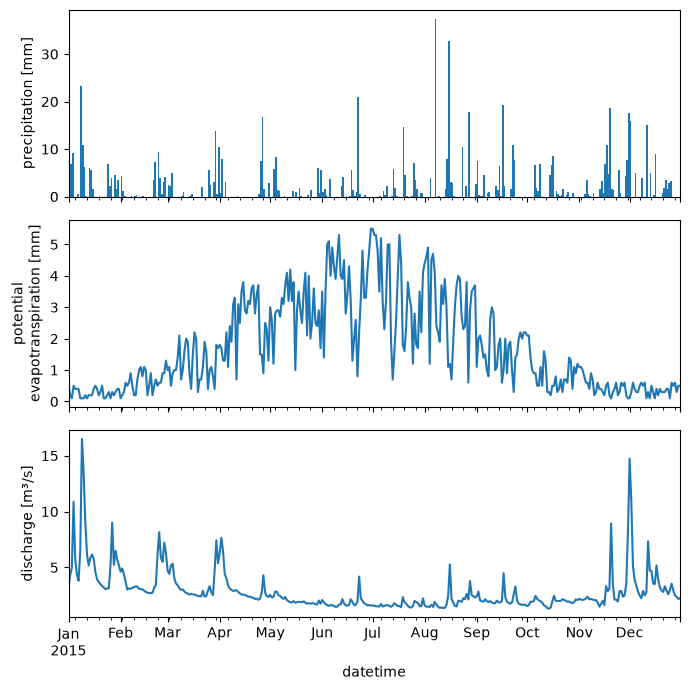

In [4]:
# Plot the data
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(7, 7))
axs[0].stairs(
    edges=df.index.append(pd.Index([df.index[-1] + pd.Timedelta("1 day")])),
    values=df["precipitation"],
    fill=True,
    baseline=0,
)
axs[0].set_ylabel("precipitation [mm]")
df["evapotranspiration"].plot(ax=axs[1])
axs[1].set_ylabel("potential\nevapotranspiration [mm]")
df["discharge [m3/s]"].plot(ax=axs[2])
axs[2].set_ylabel("discharge [m³/s]")

plt.tight_layout()

In [5]:
#will solve ODE with top two data sets and then compute discharge from our solution and compare to the measured values.

In [12]:
# Implement functions to define the right-hand side of the model


def precipitation(t, t0="2015-01-01"):
    "Select precipitation at time t using piecewise-constant interpolation"
    t0 = pd.to_datetime(t0)
    dt = pd.Timedelta(t, unit="days")
    timestamp = t0 + dt
    return df.precipitation.loc[:timestamp].iloc[-1]


def potential_evapotranspiration(t, t0="2015-01-01"):
    "Select potential evapotranspiration at time t using piecewise-constant interpolation"
    t0 = pd.to_datetime(t0)
    dt = pd.Timedelta(t, unit="days")
    timestamp = t0 + dt
    return df.evapotranspiration.loc[:timestamp].iloc[-1]


def rainfall_runoff_model(t, S, k, alpha, S_c):
    "Define right-hand-side of the ODE for a simple rainfall-runoff model"
    evapotranspiration = potential_evapotranspiration(t) * S / (S + S_c)
    Q = k * S**alpha
    dSdt = precipitation(t) - evapotranspiration - Q
    return dSdt

In [13]:
# Define model parameters
alpha = 2  # discharge exponent parameter (dimensionless)
k = 0.001  # mm^(1-alpha) / day
S_c = 5.0  # critical storage for actual evapotranspiration in mm
S0 = 10.0  # initial storage in mm

In [14]:
#After setting up schemes we define the functions to call in NR
#these are worked out on pen and paper first

def evaluate_g(S_next, S_prev, t_next, dt, k, alpha, S_c):
    """Evaluate the function g of which to find the root in the Newton-Raphson iterations

    Parameters
    ----------
    S_next: storage at time t_{i+1}
    S_prev: storage at time t_i
    t_next: time t_{i+1}
    dt: time increment
    k, alpha, S_c: model parameters
    """
    return S_next - S_prev - dt * rainfall_runoff_model(t_next, S_next, k, alpha, S_c)


def evaluate_g_prime(S_next, t_next, dt, k, alpha, S_c):
    "Evaluate the derivative of g"
    return 1 + dt * (
        potential_evapotranspiration(t_next) * S_c / (S_next + S_c) ** 2
        + alpha * k * S_next ** (alpha - 1)
    )

In [81]:
# Set up initial condition and time vector
dt = 0.1
times = np.arange(0, 365, dt)  # in days
n_times = len(times)

# Define algorithm options
tolerance = 1e-10 # tolerance ϵ for the Newton-Raphson iterations
# maximum number of Newton-Raphson iterations (to prevent an infinite loop)
max_iter = 50

In [82]:
# Initialize a list to store the state
S = [S0]

# Initialize the current state
S_prev = S0
n_iter = []

# Iterate over times
for i in range(1, n_times):
    t_next = times[i]
    # Initialize Newton-Raphson iterations: start with the current value as a guess
    j = 0
    S_next = S_prev
    # Choose arbitrary large error to make sure we enter the Newton iterations at least once
    error = tolerance + 1

    # Newton-Raphson iterations
    while error > tolerance and j < max_iter:
        # Compute g, g' and the error for the current value
        g = evaluate_g(S_next, S_prev, t_next, dt, k, alpha, S_c)
        g_prime = evaluate_g_prime(S_next, t_next, dt, k, alpha, S_c)
        error = np.abs(g)
        # Update the state
        S_next = S_next - g / g_prime
        j += 1
        if j >= max_iter:
            print(f"Reached maximum number of Newton iterations in time step i={i}.")
    n_iter.append(j)
    # Save state for time i
    S.append(S_next)
    S_prev = S_next

# Convert list of states to a numpy array
S = np.array(S)

In [76]:
#plotting solutions
t_end = times[-1]
t_dense = np.linspace(0, t_end, 6000)
sol = solve_ivp(
    rainfall_runoff_model,
    t_span=(0, t_end),
    y0=np.array([S0]),
    t_eval=t_dense,
    args=(k, alpha, S_c),
    max_step=0.8,
    method="BDF",
)

Text(0, 0.5, '$S$ [mm]')

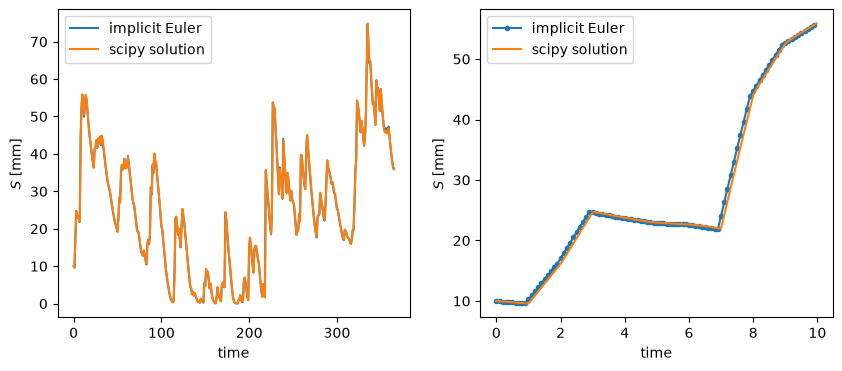

In [77]:
# Plot the implicit Euler solution against a reference solution
fig, axs = plt.subplots(ncols=2, figsize=(10, 4))
axs[0].plot(times, S, label="implicit Euler")
axs[0].plot(sol.t, sol.y[0], label="scipy solution")
axs[0].legend()
axs[0].set_xlabel("time")
axs[0].set_ylabel("$S$ [mm]")

# Zoom in to the first 10 days
mask = times < 10
mask_scipy = sol.t < 10
axs[1].plot(times[mask], S[mask], marker=".", label="implicit Euler")
axs[1].plot(sol.t[mask_scipy], sol.y[0][mask_scipy], label="scipy solution")
axs[1].legend()
axs[1].set_xlabel("time")
axs[1].set_ylabel("$S$ [mm]")

In [78]:
#When timestep increases, accuracy decreases
#when dt is 10, its just incorrect


In [79]:
#Mean2 = np.mean(n_iter)
print("for e=10^-2: Avg. Iter no. = ", Mean2 )

for e=10^-2: Avg. Iter no. =  1.9783502329405316


In [ ]:
#Mean4 = np.mean(n_iter)
print("for e=10^-4: Avg. Iter no. = ", Mean4 )

for e=10^-4: Avg. Iter no. =  2.086325020553576


In [ ]:
#Mean6 = np.mean(n_iter)
print("for e=10^-6: Avg. Iter no. = ", Mean6 )

for e=10^-6: Avg. Iter no. =  2.7870649493011785


In [83]:
Mean8 = np.mean(n_iter)
print("for e=10^-10: Avg. Iter no. = ", Mean8 )

for e=10^-10: Avg. Iter no. =  3.0271307207454097


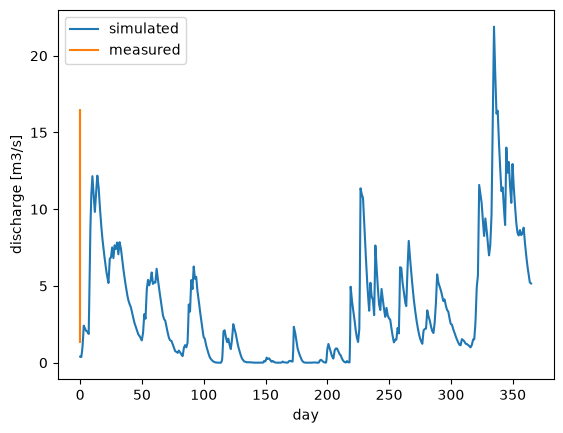

In [87]:
#Comparison of discharges:
#putting in same units
# Compute the discharge from the model output
area = 340e6  # catchment area in m²
Q_mm_per_day = k * S**alpha
Q = Q_mm_per_day * area / 1000 / 86400  # in m³/s

# Plot the simulated and measured discharge
plt.plot(times, Q, label="simulated")
plt.plot(df["days"] / 86400 / 1e9, df["discharge [m3/s]"], label="measured")
plt.xlabel("day")
plt.ylabel("discharge [m3/s]")
plt.legend()